# Running Monroe on a new dataset: ExpansionRx from OpenADMET

We will show how to use pre-trained Monroe's weights for inference on a new dataset.
As an example we will use the [OpenADMET / ExpansionRx](https://huggingface.co/datasets/openadmet/openadmet-expansionrx-challenge-data)
dataset, which consists of 9 ADMET endpoints from a real drug-discovery campaign.
Monroe has never seen these molecules or these assays.

In [1]:
import numpy as np
import pandas as pd

dataset_url = ("https://huggingface.co/datasets/openadmet/"
               "openadmet-expansionrx-challenge-data/resolve/main/")

train = pd.read_csv(dataset_url + "expansion_data_train.csv")
test = pd.read_csv(dataset_url + "expansion_data_test.csv")

endpoints = [c for c in train.columns if c not in ("Molecule Name", "SMILES")]
print(f"{len(train)} train molecules, {len(test)} test molecules")
pd.DataFrame({"train": train[endpoints].notna().sum(),
              "test": test[endpoints].notna().sum()})

5326 train molecules, 2282 test molecules


,train,test
LogD,5039,2270
KSOL,5128,2170
HLM CLint,3759,782
MLM CLint,4522,1170
Caco-2 Permeability Papp A>B,2157,1616
Caco-2 Permeability Efflux,2161,1616
MPPB,1302,454
MBPB,975,451
MGMB,222,209


## 1. Featurize and embed

`embed_smiles` does both steps: each molecule becomes a graph with 3D coordinates
(RDKit ETKDG + MMFF94s), which the encoder turns into one 720-d vector. Conformer generation
is the slow part and is pure CPU work, so it runs across a process pool; the encoder forward
pass is a batched GPU call on top.

Every unique molecule is embedded **once** and reused for all nine endpoints.

In [2]:
import torch

from monroe.eval.embed import embed_smiles
from monroe.model.ckpt import load_ckpt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encoder = load_ckpt("../checkpoint").to(device)   # bundled model (git lfs pull)

molecules = pd.unique(pd.concat([train.SMILES, test.SMILES]))
embeddings = embed_smiles(molecules, encoder)
print(f"embedded {len(embeddings)} of {len(molecules)} molecules")

/fs/gpfs41/lv11/fileset01/pool/pool-banaszewski/monroe/.release/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


embedded 7608 of 7608 molecules


## 2. Predict each endpoint with TabPFN

One loop over the nine endpoints. For each, we keep the molecules that have a measurement,
fit TabPFN on the training embeddings and predict the test set. Nothing is trained — the
encoder stays frozen and TabPFN does a single forward pass.

In [3]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score

from monroe.eval.tabpfn import default_ensemble_specs, fit_predict_tabpfn


def labelled(df, endpoint):
    """Embeddings and labels for the molecules that have this endpoint measured."""
    measured = df[["SMILES", endpoint]].dropna()
    measured = measured[measured.SMILES.isin(embeddings)]
    return (np.stack([embeddings[s] for s in measured.SMILES]),
            measured[endpoint].to_numpy())


def predict(endpoint):
    X_train, y_train = labelled(train, endpoint)
    X_test, y_test = labelled(test, endpoint)
    y_pred = fit_predict_tabpfn(X_train, y_train, X_test, is_classification=False,
                                ensemble_specs=default_ensemble_specs(), seed=42)
    return y_test, y_pred, len(y_train)


scores = []
for endpoint in endpoints:
    y_test, y_pred, n_train = predict(endpoint)
    scores.append({"endpoint": endpoint,
                   "n_train": n_train,
                   "n_test": len(y_test),
                   "R2": r2_score(y_test, y_pred),
                   "MAE": mean_absolute_error(y_test, y_pred),
                   "Spearman": spearmanr(y_test, y_pred).statistic})

pd.DataFrame(scores).set_index("endpoint").round(3)

,n_train,n_test,R2,MAE,Spearman
endpoint,,,,,
LogD,5039,2270,0.725,0.399,0.862
KSOL,5128,2170,0.336,73.354,0.582
HLM CLint,3759,782,0.181,23.889,0.616
MLM CLint,4522,1170,0.009,236.843,0.493
Caco-2 Permeability Papp A>B,2157,1616,0.368,4.124,0.666
Caco-2 Permeability Efflux,2161,1616,0.028,15.364,0.745
MPPB,1302,454,0.187,8.765,0.644
MBPB,975,451,0.363,3.290,0.824
MGMB,222,209,0.506,3.928,0.794


## 3. How does that compare?

OpenADMET's own baseline for this challenge was built on the **CheMeleon** foundation model,
and they published its LogD numbers in their
[write-up](https://openadmet.ghost.io/zero-shot-expansiorx-admet-predictions/):

| model | R² | MAE | Spearman |
|:---|:---|:---|:---|
| Monroe | **0.73** | **0.40** | **0.86** |
| CheMeleon baseline | 0.50 | 0.57 | 0.70 |

Monroe significantly outperforms the baseline on all three metrics.

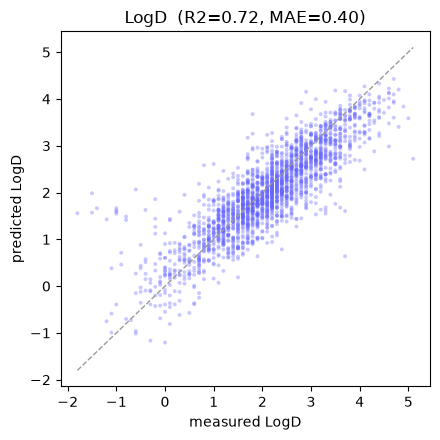

In [4]:
import matplotlib.pyplot as plt

y_test, y_pred, _ = predict("LogD")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(y_test, y_pred, s=8, alpha=0.35, edgecolors="none", color="#6666FF")
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, "--", color="#999999", linewidth=1)
ax.set_xlabel("measured LogD")
ax.set_ylabel("predicted LogD")
ax.set_title(f"LogD  (R2={r2_score(y_test, y_pred):.2f}, "
             f"MAE={mean_absolute_error(y_test, y_pred):.2f})")
fig.tight_layout()

## Using your own data

Swap the two `read_csv` calls for your own table. All the notebook needs is a `SMILES` column
plus one or more label columns; everything downstream is unchanged. For classification, pass
`is_classification=True` to `fit_predict_tabpfn`, which then returns `(labels, probabilities)`.